# MovieLens (ml-latest-small) — EDA
Following `docs/eda_checklist.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

DATA_DIR = "../../data/raw/prototype/movielens/ml-latest-small"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")
movies = pd.read_csv(f"{DATA_DIR}/movies.csv")
tags = pd.read_csv(f"{DATA_DIR}/tags.csv")
links = pd.read_csv(f"{DATA_DIR}/links.csv")

for name, df in [("ratings", ratings), ("movies", movies), ("tags", tags), ("links", links)]:
    print(name, df.shape)

ratings (100836, 4)
movies (9742, 3)
tags (3683, 4)
links (9742, 3)


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.dtypes

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

In [6]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings.dtypes

userId               int64
movieId              int64
rating             float64
timestamp            int64
datetime     datetime64[s]
dtype: object

## 2. Missing Values

In [7]:
for name, df in [("ratings", ratings), ("movies", movies), ("tags", tags), ("links", links)]:
    print(f"--- {name} ---")
    print((df.isna().mean() * 100).round(2))

--- ratings ---
userId       0.0
movieId      0.0
rating       0.0
timestamp    0.0
datetime     0.0
dtype: float64
--- movies ---
movieId    0.0
title      0.0
genres     0.0
dtype: float64
--- tags ---
userId       0.0
movieId      0.0
tag          0.0
timestamp    0.0
dtype: float64
--- links ---
movieId    0.00
imdbId     0.00
tmdbId     0.08
dtype: float64


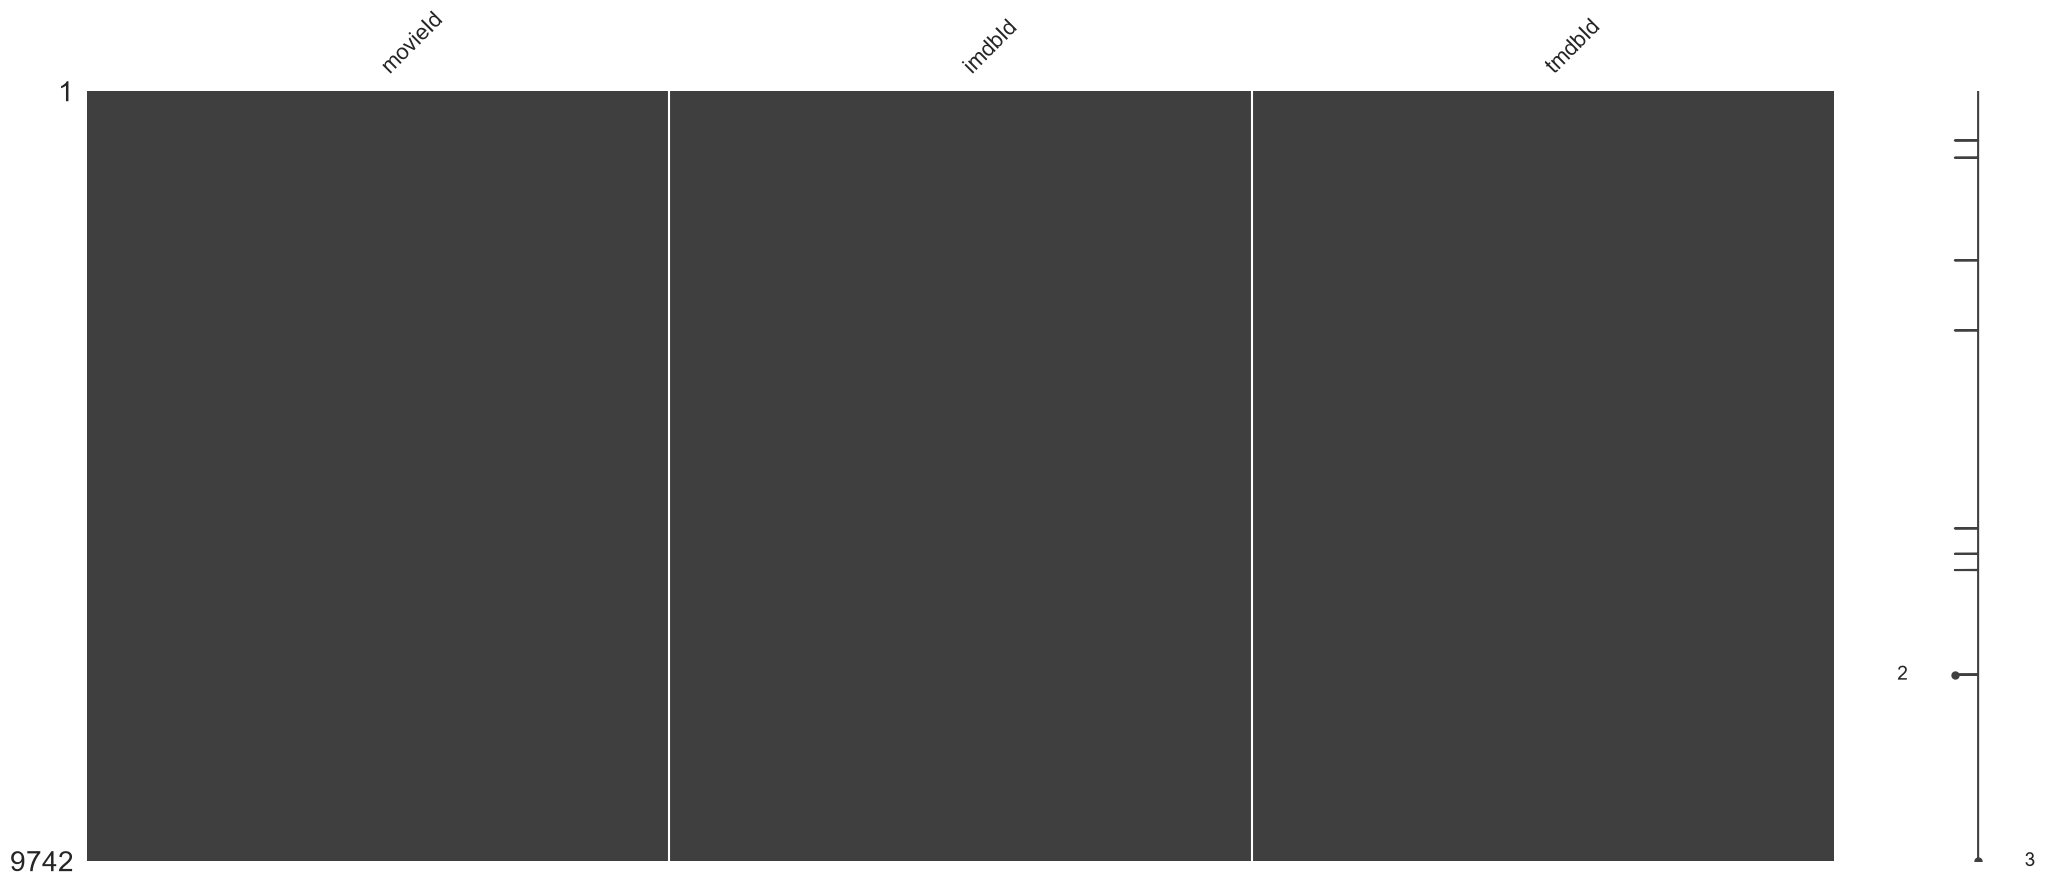

In [8]:
msno.matrix(links); plt.show()

Decision: `links.tmdbId` missing rows — flag, keep (only used for cross-reference, not core rating data).

## 3. Duplicates

In [9]:
print("full-row dup ratings:", ratings.duplicated().sum())
print("dup (userId, movieId) key:", ratings.duplicated(subset=["userId", "movieId"]).sum())
print("dup movieId in movies:", movies.duplicated(subset=["movieId"]).sum())

full-row dup ratings: 0
dup (userId, movieId) key: 0
dup movieId in movies: 0


## 4. Univariate Analysis

In [10]:
ratings["rating"].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

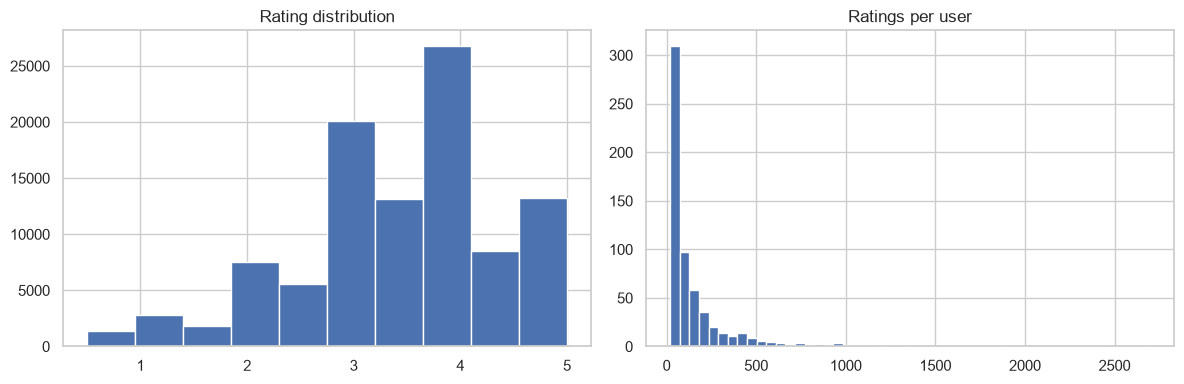

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ratings["rating"].hist(bins=10, ax=ax[0])
ax[0].set_title("Rating distribution")
ratings.groupby("userId").size().hist(bins=50, ax=ax[1])
ax[1].set_title("Ratings per user")
plt.tight_layout(); plt.show()

In [12]:
genres = movies["genres"].str.split("|").explode()
genres.value_counts()

genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

## 5. Outliers

upper bound: 367.5 | users above bound: 70


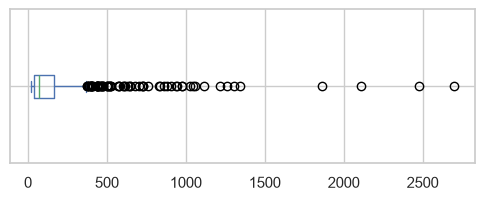

In [13]:
counts_per_user = ratings.groupby("userId").size()
q1, q3 = counts_per_user.quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print("upper bound:", upper, "| users above bound:", (counts_per_user > upper).sum())
counts_per_user.plot(kind="box", vert=False, figsize=(6, 2)); plt.show()

Decision: high-count users = power raters, real signal not error — keep.

## 6. Target Variable
N/A — no supervised task defined yet. `rating` could serve as regression target later; revisit once modeling task chosen.

## 7. Bivariate / Correlation Analysis

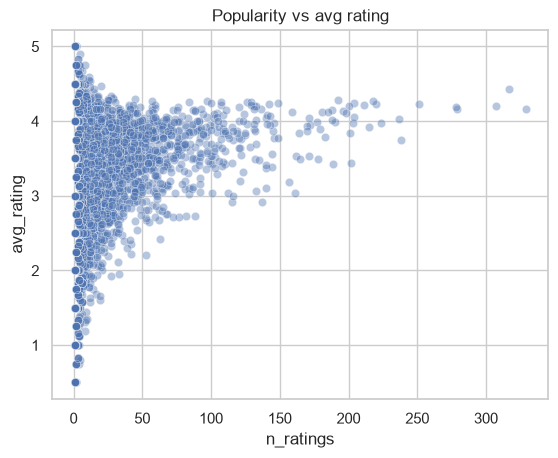

In [14]:
movie_stats = ratings.groupby("movieId").agg(avg_rating=("rating", "mean"), n_ratings=("rating", "count"))
sns.scatterplot(data=movie_stats, x="n_ratings", y="avg_rating", alpha=0.4)
plt.title("Popularity vs avg rating"); plt.show()

## 8. Time-based Checks

date range: 1996-03-29 18:36:55 to 2018-09-24 14:27:30


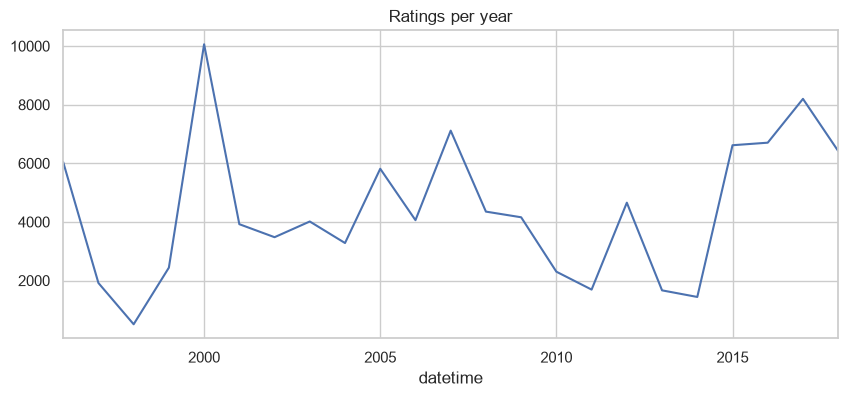

In [15]:
print("date range:", ratings["datetime"].min(), "to", ratings["datetime"].max())
ratings.set_index("datetime").resample("YE").size().plot(figsize=(10, 4), title="Ratings per year")
plt.show()

## 9. Data Consistency

In [16]:
print("rating range ok:", ratings["rating"].between(0.5, 5).all())
print("movieId in ratings but not in movies:", (~ratings["movieId"].isin(movies["movieId"])).sum())
print("movieId in tags but not in movies:", (~tags["movieId"].isin(movies["movieId"])).sum())

rating range ok: True
movieId in ratings but not in movies: 0
movieId in tags but not in movies: 0


## 10. Feature Relationships for Recommendation Context

In [17]:
n_users = ratings["userId"].nunique()
n_items = ratings["movieId"].nunique()
n_interactions = len(ratings)
sparsity = 1 - n_interactions / (n_users * n_items)
print(f"users={n_users} items={n_items} interactions={n_interactions} sparsity={sparsity:.4%}")

users=610 items=9724 interactions=100836 sparsity=98.3000%


items with <=2 ratings: 4744 (48.8%)
users with <=2 ratings: 0 (0.0%)


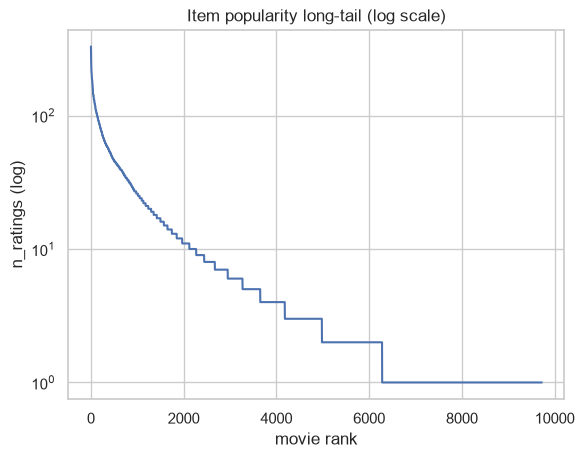

In [18]:
item_counts = ratings.groupby("movieId").size().sort_values(ascending=False)
cold_start_items = (item_counts <= 2).sum()
cold_start_users = (ratings.groupby("userId").size() <= 2).sum()
print("items with <=2 ratings:", cold_start_items, f"({cold_start_items/n_items:.1%})")
print("users with <=2 ratings:", cold_start_users, f"({cold_start_users/n_users:.1%})")

item_counts.reset_index(drop=True).plot(logy=True, title="Item popularity long-tail (log scale)")
plt.xlabel("movie rank"); plt.ylabel("n_ratings (log)"); plt.show()

## 11. Summary

- Shape: 100k ratings, ~600 users, ~9700 movies, small clean prototype set.
- Missing: only `links.tmdbId` has gaps, non-core, safe ignore.
- Duplicates: none on (userId, movieId), none on movieId in movies.
- Rating scale 0.5–5, half-star steps, no invalid values.
- Referential integrity: ratings/tags movieId fully covered by movies table.
- Sparsity extremely high (>98%) — typical for rec systems, expect worse at Expedia/Airbnb/Trivago scale.
- Long-tail popularity confirmed — most movies have very few ratings, handful dominate.
- No explicit supervised target chosen yet — `rating` candidate for regression/ranking task.
- Good baseline dataset for prototyping CF/ranking pipeline before scaling to bigger domains.